In [16]:
# import tensorflow as tf
# config = tf.compat.v1.ConfigProto()
# config.gpu_options.allow_growth = True
# session = tf.compat.v1.Session(config=config)

from tensorflow import keras
# print(tf.__version__)
# import os
# import tempfile
import joblib
# 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import seaborn as sns
from ete3 import Tree
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from itertools import permutations
from matplotlib import rcParams
import seaborn as sns
# from util import *
# from visualisation import *

# load calculated metrics

In [17]:
ara = pd.read_csv("../../data/features_screen/feat_arabidopsis.csv")
asgard = pd.read_csv("../../data/features_screen/feat_asgard.csv")
celegans = pd.read_csv("../../data/features_screen/feat_celegans.csv")
cyano = pd.read_csv("../../data/features_screen/feat_cyano.csv")
DPANN = pd.read_csv("../../data/features_screen/feat_DPANN.csv")
ecoli = pd.read_csv("../../data/features_screen/feat_ecoli.csv")
mus = pd.read_csv("../../data/features_screen/feat_mus.csv")
hum = pd.read_csv("../../data/features_screen/feat_homo.csv")
sacch = pd.read_csv("../../data/features_screen/feat_sacch.csv")
strep = pd.read_csv("../../data/features_screen/feat_strep.csv")

organism_datasets = {
    'arabidopsis': ara,
    'asgard': asgard, 
    'celegans': celegans,
    'cyano': cyano,
    'DPANN': DPANN,
    'ecoli': ecoli,
    'mus': mus,
    'homo': hum,
    'sacch': sacch,
    'strep': strep
}

# classify structures

In [18]:
try:
    model_path = '../../predict/models/model_1.keras'
    model = keras.models.load_model(model_path)
except Exception as e:
    print(f"Error loading model: {str(e)}")
    raise

try:
    scaler = joblib.load("../../predict/code/scaler.pkl")
except Exception as e:
    print(f"Error loading scaler: {str(e)}")
    raise

all_results = {}

for organism_name, dataframe in organism_datasets.items():

    df_work = dataframe.copy()
    # test_y = np.array(df_work.pop('type'))
    name = np.array(df_work.pop('name'))

    feature_columns = ['-logP_Struc', '-logP_Contact', "area_sc", 'per_con', 'per_no_con', 'contact_order']
    X = np.array(df_work[feature_columns])
    X = scaler.transform(X)

    pred = model.predict(X, batch_size=32)

    result = []
    for prediction, name in zip(pred, name):
        result.append([prediction[0], name])


    # Convert to array and sort by score
    result = np.array(result)
    scores = result[:, 0].astype(float)
    sorted_indices = np.argsort(scores)[::-1]  # Sort descending
    sorted_data = result[sorted_indices]

    # Extract UniProt IDs from names
    names_col = sorted_data[:, 1]
    scores_col = sorted_data[:, 0].astype(float)

    # Extract UniProt IDs (assuming format like "something-UNIPROT_ID")
    uniprot_ids = []
    for name in names_col:
        try:
            uniprot_id = name.split('-')[1] if '-' in name else name
            uniprot_ids.append(uniprot_id)
        except IndexError:
            uniprot_ids.append(name)

    # Create results dataframe
    results_df = pd.DataFrame({
        'UniProtID': uniprot_ids,
        'scores': np.round(scores_col, 3)
    })
    
    all_results[organism_name] = results_df
    results_df.to_csv(f"../../data/predictions_screen/pred_{organism_name}.csv", index=False)
    print(f"Predictions for {organism_name} completed.")


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predictions for arabidopsis completed.
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 0s 292us/step
Predictions for asgard completed.
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step
Predictions for celegans completed.
1744/1744 ━━━━━━━━━━━━━━━━━━━━ 1s 287us/step
Predictions for cyano completed.
3128/3128 ━━━━━━━━━━━━━━━━━━━━ 1s 293us/step
Predictions for DPANN completed.
919/919 ━━━━━━━━━━━━━━━━━━━━ 0s 288us/step
Predictions for ecoli completed.
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step
Predictions for mus completed.
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step
Predictions for homo completed.
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step
Predictions for sacch completed.
4460/4460 ━━━━━━━━━━━━━━━━━━━━ 1s 302us/step
Predictions for strep completed.


In [19]:
info_ara = pd.read_csv("../../data/sequence_info/info_arabidopsis.csv")
info_asgard = pd.read_csv("../../data/sequence_info/info_asgard.csv")
info_celegans = pd.read_csv("../../data/sequence_info/info_celegans.csv")
info_cyano = pd.read_csv("../../data/sequence_info/info_cyano.csv")
info_DPANN = pd.read_csv("../../data/sequence_info/info_dpann.csv")
info_ecoli = pd.read_csv("../../data/sequence_info/info_ecoli.csv")
info_mus = pd.read_csv("../../data/sequence_info/info_mus.csv")
info_hum = pd.read_csv("../../data/sequence_info/info_homo.csv")
info_sacch = pd.read_csv("../../data/sequence_info/info_sacchmyc.csv")  
info_strep = pd.read_csv("../../data/sequence_info/info_strep.csv")

In [20]:
# Map organism names to their info DataFrames
info_dfs = {
    'arabidopsis': info_ara,
    'asgard': info_asgard,
    'celegans': info_celegans,  
    'cyano': info_cyano,
    'DPANN': info_DPANN,
    'ecoli': info_ecoli,        
    'mus': info_mus,            
    'homo': info_hum,          
    'sacch': info_sacch,
    'strep': info_strep
}

# Add Os, ID, Sequence columns from info DataFrames to results DataFrames
for organism, results_df in all_results.items():
    if (
        results_df is not None
        and not results_df.empty
    ):
        # Handle the homo/human naming mismatch
        # info_key = 'human' if organism == 'homo' else organism
        
        if organism in info_dfs:
            info_df = info_dfs[organism]
            # Only merge if 'protein_id' exists in info_df and 'UniProtID' in results_df
            if 'protein_id' in info_df.columns and 'UniProtID' in results_df.columns:
                merged = pd.merge(
                    results_df,
                    info_df[['organism', 'protein_id', 'sequence']],
                    left_on='UniProtID',
                    right_on='protein_id',
                    how='left'
                )
                all_results[organism] = merged
            else:
                print(f"Skipping {organism}: required columns missing in info/results DataFrame.")
        else:
            print(f"Skipping {organism}: no matching info DataFrame found for key '{organism}'")

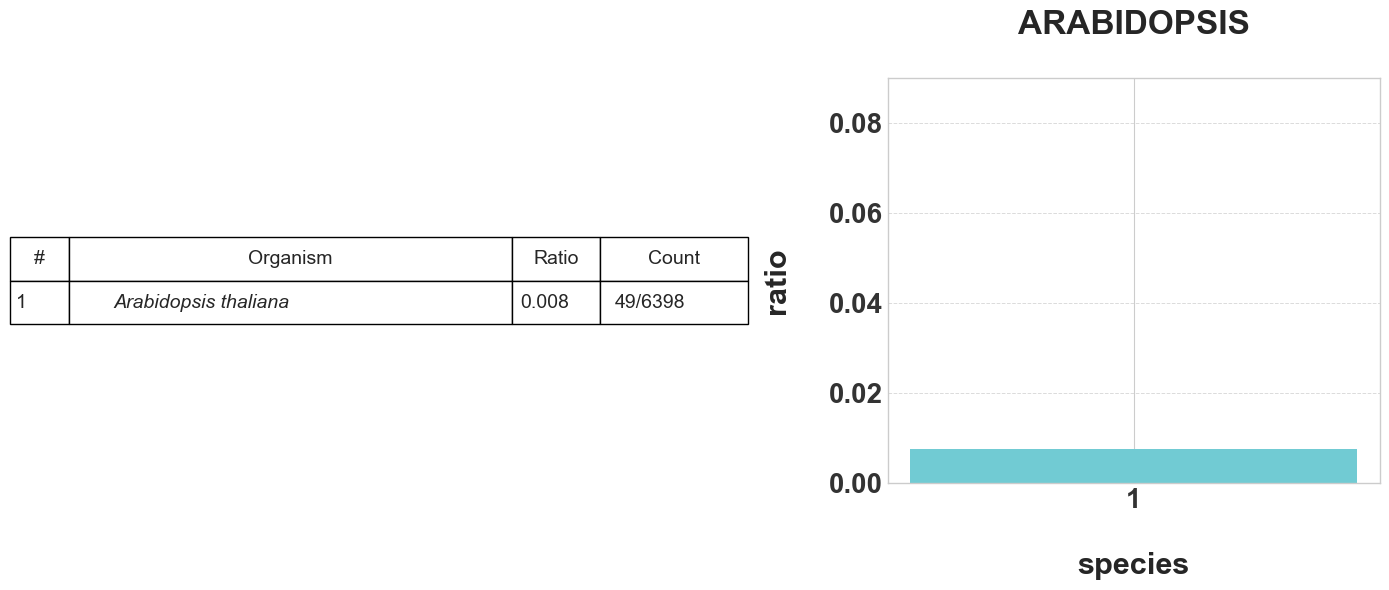


ARABIDOPSIS Summary:
  Total entries: 6398
  Entries after filtering (>= 1000): 6398
  Top 7 organisms by count:
    1. Arabidopsis thaliana: 0.008 (49/6398)


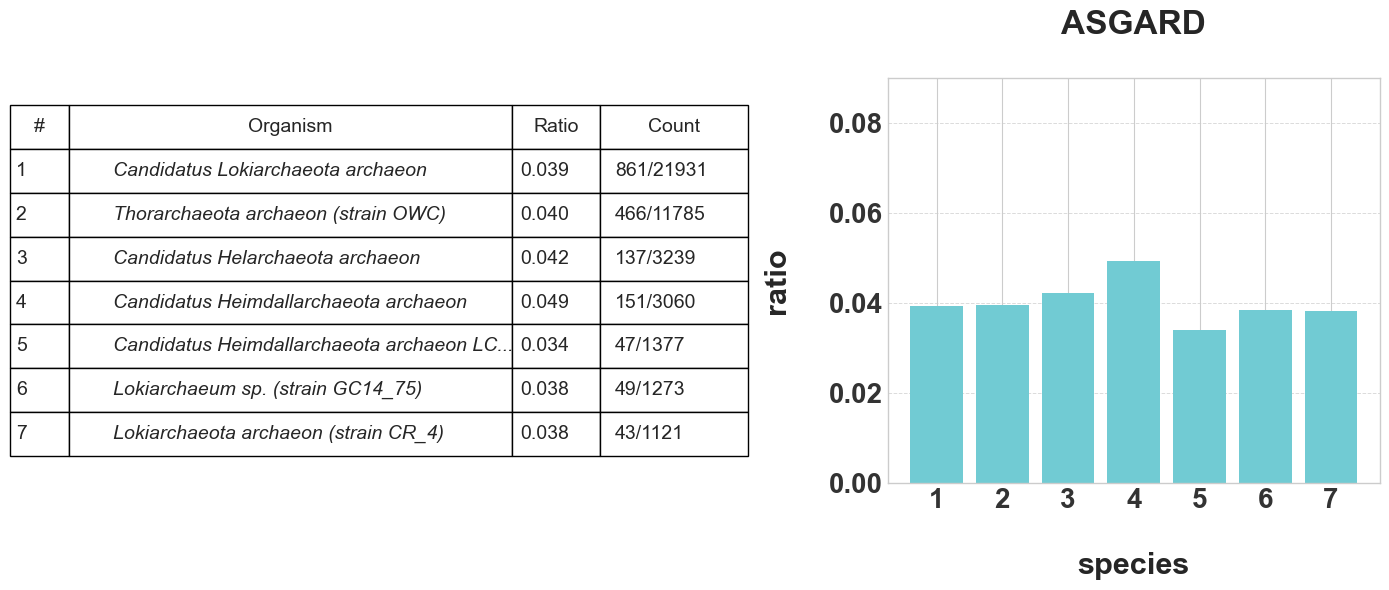


ASGARD Summary:
  Total entries: 51004
  Entries after filtering (>= 1000): 44887
  Top 7 organisms by count:
    1. Candidatus Lokiarchaeota archaeon: 0.039 (861/21931)
    2. Thorarchaeota archaeon (strain OWC): 0.040 (466/11785)
    3. Candidatus Helarchaeota archaeon: 0.042 (137/3239)
    4. Candidatus Heimdallarchaeota archaeon: 0.049 (151/3060)
    5. Candidatus Heimdallarchaeota archaeon LC_3: 0.034 (47/1377)
    6. Lokiarchaeum sp. (strain GC14_75): 0.038 (49/1273)
    7. Lokiarchaeota archaeon (strain CR_4): 0.038 (43/1121)


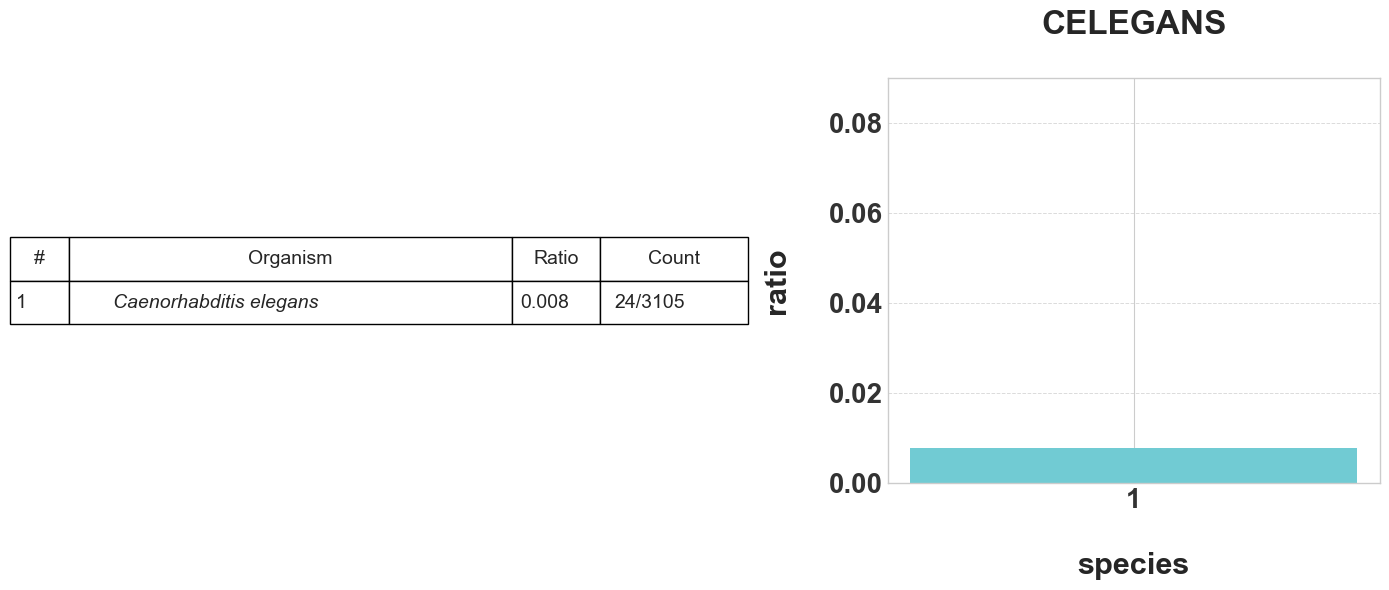


CELEGANS Summary:
  Total entries: 3105
  Entries after filtering (>= 1000): 3105
  Top 7 organisms by count:
    1. Caenorhabditis elegans: 0.008 (24/3105)


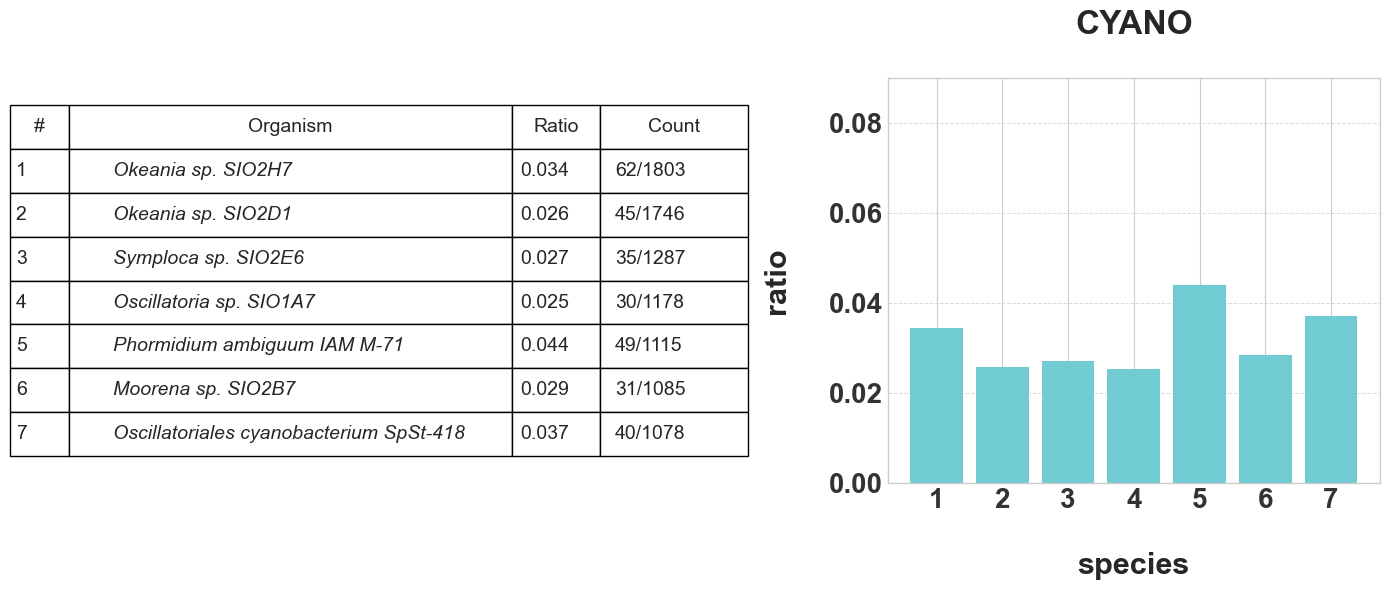


CYANO Summary:
  Total entries: 55788
  Entries after filtering (>= 1000): 11386
  Top 7 organisms by count:
    1. Okeania sp. SIO2H7: 0.034 (62/1803)
    2. Okeania sp. SIO2D1: 0.026 (45/1746)
    3. Symploca sp. SIO2E6: 0.027 (35/1287)
    4. Oscillatoria sp. SIO1A7: 0.025 (30/1178)
    5. Phormidium ambiguum IAM M-71: 0.044 (49/1115)
    6. Moorena sp. SIO2B7: 0.029 (31/1085)
    7. Oscillatoriales cyanobacterium SpSt-418: 0.037 (40/1078)


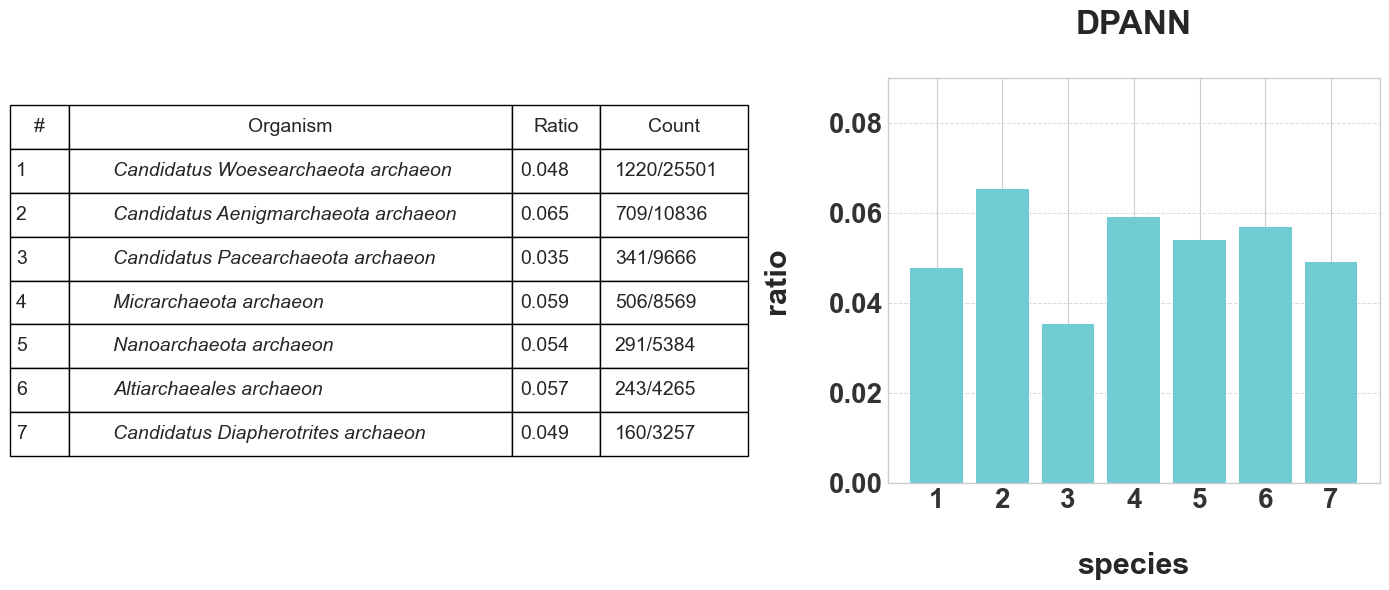


DPANN Summary:
  Total entries: 100076
  Entries after filtering (>= 1000): 67478
  Top 7 organisms by count:
    1. Candidatus Woesearchaeota archaeon: 0.048 (1220/25501)
    2. Candidatus Aenigmarchaeota archaeon: 0.065 (709/10836)
    3. Candidatus Pacearchaeota archaeon: 0.035 (341/9666)
    4. Micrarchaeota archaeon: 0.059 (506/8569)
    5. Nanoarchaeota archaeon: 0.054 (291/5384)
    6. Altiarchaeales archaeon: 0.057 (243/4265)
    7. Candidatus Diapherotrites archaeon: 0.049 (160/3257)


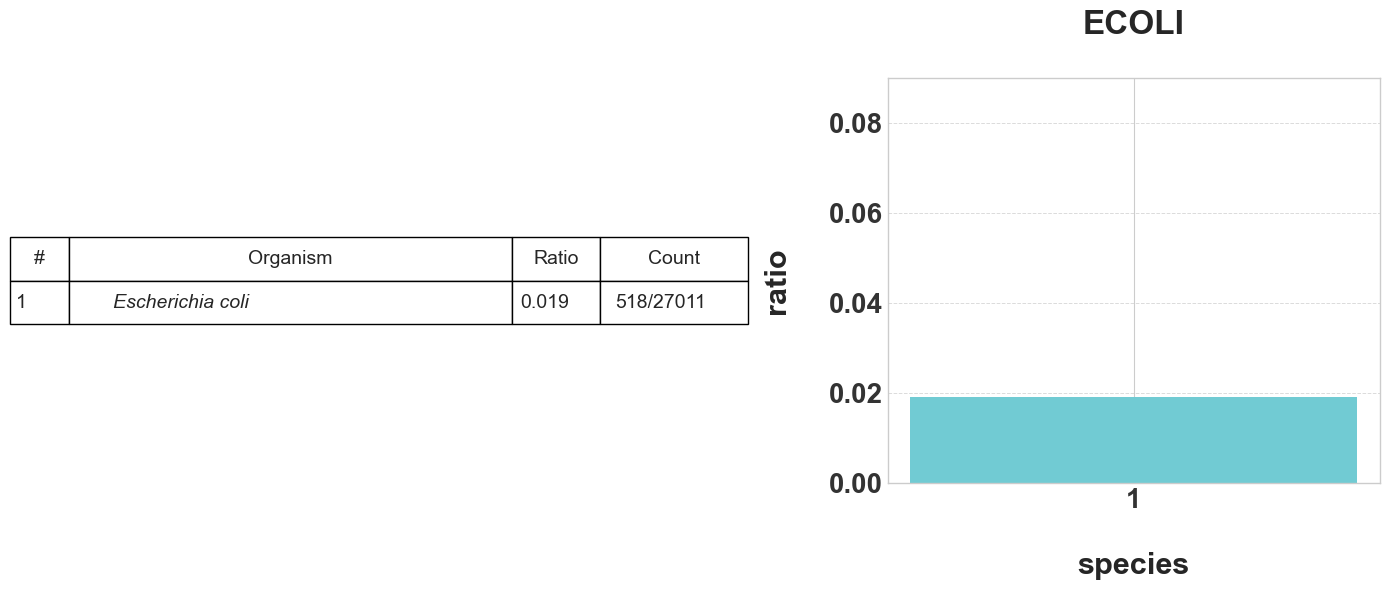


ECOLI Summary:
  Total entries: 29405
  Entries after filtering (>= 1000): 27011
  Top 7 organisms by count:
    1. Escherichia coli: 0.019 (518/27011)


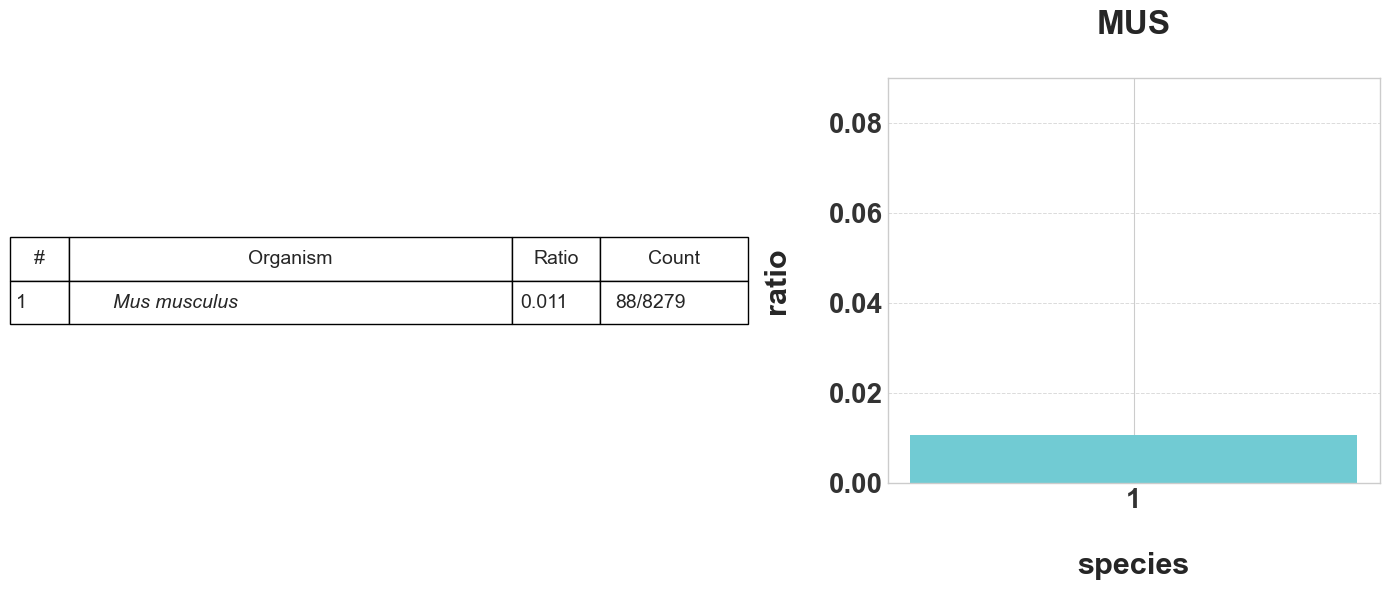


MUS Summary:
  Total entries: 8329
  Entries after filtering (>= 1000): 8279
  Top 7 organisms by count:
    1. Mus musculus: 0.011 (88/8279)


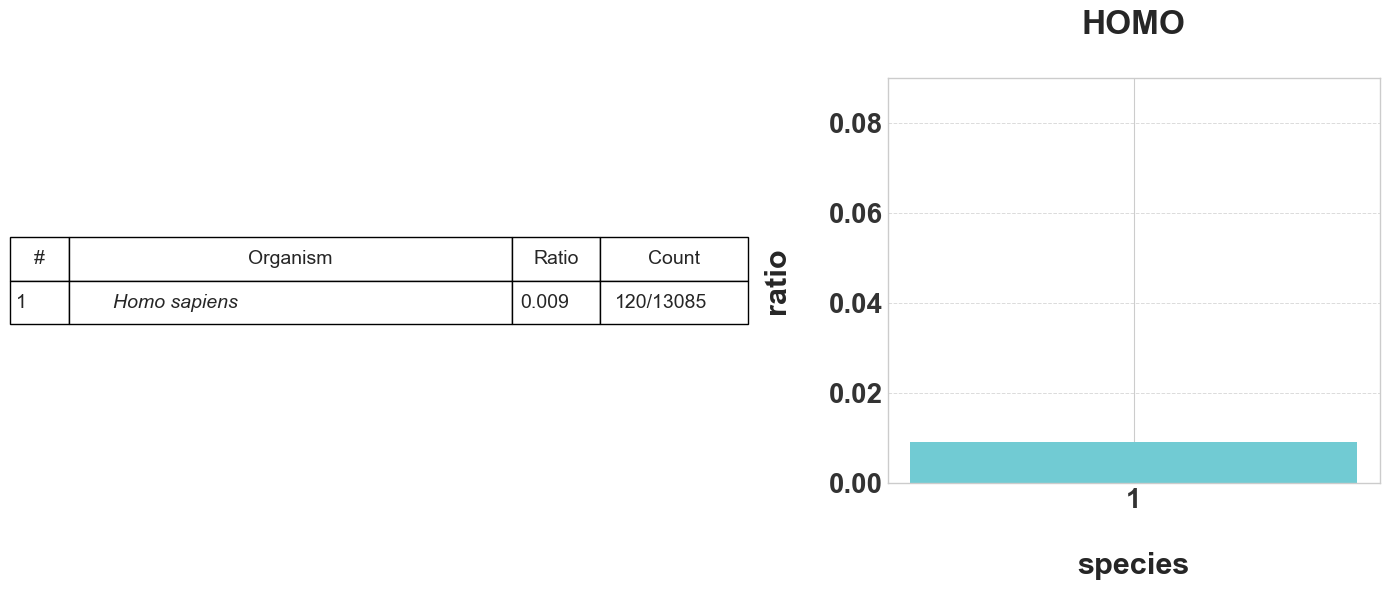


HOMO Summary:
  Total entries: 13085
  Entries after filtering (>= 1000): 13085
  Top 7 organisms by count:
    1. Homo sapiens: 0.009 (120/13085)
No organisms with >= 1000 entries for sacch


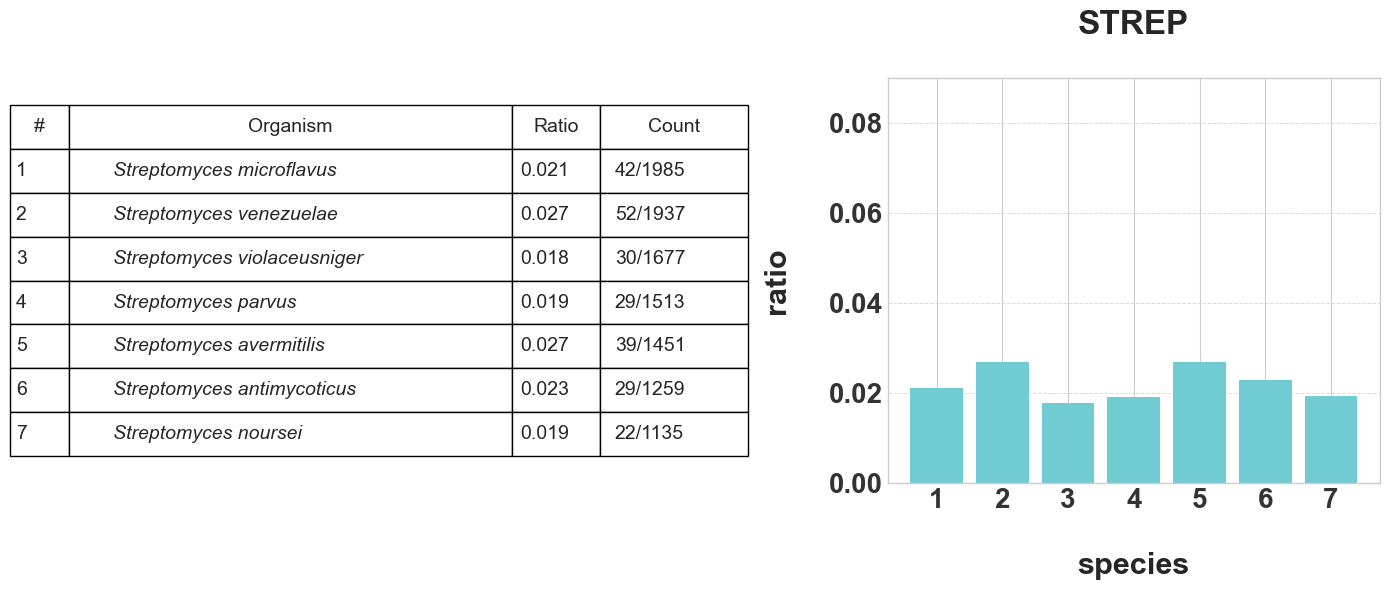


STREP Summary:
  Total entries: 142714
  Entries after filtering (>= 1000): 18279
  Top 7 organisms by count:
    1. Streptomyces microflavus: 0.021 (42/1985.0)
    2. Streptomyces venezuelae: 0.027 (52/1937.0)
    3. Streptomyces violaceusniger: 0.018 (30/1677.0)
    4. Streptomyces parvus: 0.019 (29/1513.0)
    5. Streptomyces avermitilis: 0.027 (39/1451.0)
    6. Streptomyces antimycoticus: 0.023 (29/1259.0)
    7. Streptomyces noursei: 0.019 (22/1135.0)


In [21]:
# Create individual plots for each dataframe following the exact format
def create_individual_plots(dataframes, score_col_name='scores', os_col_name='organism_x', STD_COLOR='0.2'):
    """
    Create individual plots for each dataframe following the exact format
    
    Parameters:
    - dataframes: dict of dataframes
    - score_col_name: name of the score column (default 'scores')
    - os_col_name: name of the OS/organism column (default 'organism_x')
    - STD_COLOR: color for tick marks (default '0.2')
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    for name, df in dataframes.items():
        # Check if required columns exist, try alternative column names if not
        if score_col_name not in df.columns:
            print(f"Skipping {name}: missing score column '{score_col_name}'")
            continue
            
        # Try different organism column names
        organism_col = None
        for col_option in ['organism_x', 'organism_y', 'organism']:
            if col_option in df.columns:
                organism_col = col_option
                break
        
        if organism_col is None:
            print(f"Skipping {name}: no organism column found")
            continue
        
        # Extract org name from dataframe name
        org = name.replace('info_', '').upper()
        
        # Process data following exact format
        score_table = df.copy()
        
        # Merge organism data - use the identified organism column
        os_counts = score_table[organism_col].value_counts().reset_index()
        os_counts.columns = [organism_col, 'count']
        score_table = score_table.merge(os_counts, on=organism_col, how='left')
        
        # Calculate denovolikeness based on score
        score_table['denovo'] = (score_table[score_col_name] > 0.5).astype(int)
        
        # Filter rows with count >= 1000
        score = score_table[score_table['count'] >= 1000]
        
        if len(score) == 0:
            print(f"No organisms with >= 1000 entries for {name}")
            continue
            
        # Denovo per organism
        denovo_counts = score[score['denovo'] == 1].groupby(organism_col).size().reset_index(name='denovo_count')
        score = score.merge(denovo_counts, on=organism_col, how='left')
        score['denovo_count'] = score['denovo_count'].fillna(0).astype(int)
        
        # Create publication-ready figure
        plt.style.use('seaborn-v0_8-whitegrid')
        
        # Calculate statistics
        grouped = score.groupby(organism_col).agg({
            'denovo_count': 'first',
            'count': 'first'
        }).reset_index()
        
        grouped['ratio'] = grouped['denovo_count'] / grouped['count']
        grouped['error'] = np.sqrt((grouped['ratio'] * (1 - grouped['ratio'])) / grouped['count'])
        
        # Filter to top 7 biggest counts
        grouped = grouped.nlargest(7, 'count')
        
        # Create figure with subplots: table on left, bar chart on right
        fig, (ax_table, ax_bar) = plt.subplots(1, 2, figsize=(14, 6), 
                                               gridspec_kw={'width_ratios': [1, 1]})
        
        # Create table data
        table_data = []
        for i, (_, row) in enumerate(grouped.iterrows()):
            table_data.append([
                f"{i+1}",
                row[organism_col][:40] + "..." if len(row[organism_col]) > 40 else row[organism_col],
                f"{row['ratio']:.3f}",
                f"{row['denovo_count']}/{row['count']:.0f}"
            ])
        
        # Create table
        ax_table.axis('tight')
        ax_table.axis('off')
        
        table = ax_table.table(cellText=table_data,
                              colLabels=['#', 'Organism', 'Ratio', 'Count'],
                              cellLoc='left',
                              loc='center',
                              colWidths=[0.08, 0.6, 0.12, 0.2])
        
        # Style the table
        table.auto_set_font_size(False)
        table.set_fontsize(14)
        table.scale(1.5, 3)
        # Make Organism column italic in table
        for i in range(1, len(table_data) + 1):
            cell = table[(i, 1)]
            cell.set_text_props(fontstyle='italic')
            # for j in range(4):
            #     table[(i, j)].set_facecolor('#F8F8F8')

        # Create bar plot
        bars = ax_bar.bar(range(len(grouped)), grouped['ratio'], color='#71cbd3', width=0.8)
        
        # Customize the bar plot
        ax_bar.set_xticks(range(len(grouped)))
        ax_bar.set_xticklabels([str(i+1) for i in range(len(grouped))], fontsize=20, fontweight='bold')
        ax_bar.tick_params(axis='y', labelsize=20, colors=STD_COLOR)
        
        # Make y-axis labels bold to match x-axis style
        for label in ax_bar.get_yticklabels():
            label.set_fontweight('bold')
        ax_bar.set_xlabel('\nspecies', fontsize=22, fontweight='bold')
        ax_bar.set_ylabel('ratio\n', fontsize=22, fontweight='bold')
        ax_bar.set_title(f'{org}\n', fontsize=24, fontweight='bold')
        ax_bar.set_ylim(0, 0.09)
        
        # Add gridlines for better readability
        ax_bar.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
        ax_bar.tick_params(axis='x', colors=STD_COLOR)
        ax_bar.tick_params(axis='y', colors=STD_COLOR)
        
        # Add summary information as text annotation
        total_entries = len(score_table)
        filtered_entries = len(score)
        unique_organisms = len(grouped)
        
        # Calculate overall statistics
        total_denovo = score_table['denovo'].sum()
        overall_ratio = total_denovo / total_entries if total_entries > 0 else 0
                
        # Show the plot
        plt.tight_layout()
        plt.savefig(f'dist_{org}.png', bbox_inches='tight', dpi=300)
        plt.show()
        
        # Print summary
        print(f"\n{org} Summary:")
        print(f"  Total entries: {len(score_table)}")
        print(f"  Entries after filtering (>= 1000): {len(score)}")
        print(f"  Top 7 organisms by count:")
        for i, (_, row) in enumerate(grouped.iterrows()):
            print(f"    {i+1}. {row[organism_col]}: {row['ratio']:.3f} ({row['denovo_count']}/{row['count']})")

# Create the individual plots
STD_COLOR = '0.2'

create_individual_plots(all_results)

In [22]:
# Use all_results and filter for specific organisms per dataset
plot_data = []

# Mapping of datasets to specific organisms to filter and their display names
organism_filters = {
    'DPANN': ('Nanoarchaeota archaeon', 'Nanoarchaeota'),
    'asgard': ('Thorarchaeota archaeon (strain OWC)', 'Thorarchaeota'),
    'ecoli': ('Escherichia coli', 'E. coli'),
    'cyano': ('Moorena sp. SIO2B7', 'Moorena sp.'),
    'strep': ('Streptomyces noursei', 'S. noursei'),
    'arabidopsis': ('Arabidopsis thaliana', 'A. thaliana'),
    'sacch': ('Saccharomyces cerevisiae', 'S. cerevisiae'),  # Keep as requested by user
    'celegans': ('Caenorhabditis elegans', 'C. elegans'),
    'mus': ('Mus musculus', 'M. musculus'),
    'homo': ('Homo sapiens', 'H. sapiens')
}

for organism_name, results_df in all_results.items():
    if len(results_df) > 0 and organism_name in organism_filters:
        target_organism, display_name = organism_filters[organism_name]
        
        # Special case for sacch: use all datapoints
        if organism_name == 'sacch':
            filtered_df = results_df.copy()
            high_score_predictions = len(filtered_df[filtered_df['scores'] > 0.5])
            total_predictions = len(filtered_df)
            high_score_percentage = (high_score_predictions / total_predictions) * 100
            
            plot_data.append({
                'organism': display_name,
                'dataset': organism_name,
                'target_organism': 'All Saccharomyces species',
                'total_predictions': total_predictions,
                'high_score_predictions': high_score_predictions,
                'high_score_percentage': high_score_percentage
            })
            print(f"{organism_name}: Using all {total_predictions} entries (all Saccharomyces species)")
            continue
        
        # Check which organism column exists
        organism_col = None
        for col_option in ['organism', 'organism_x', 'organism_y']:
            if col_option in results_df.columns:
                organism_col = col_option
                break
        
        if organism_col is None:
            print(f"Skipping {organism_name}: no organism column found")
            continue
        
        # Filter for the specific organism
        filtered_df = results_df[results_df[organism_col] == target_organism]
        
        if len(filtered_df) == 0:
            # If exact match not found, try partial match
            filtered_df = results_df[results_df[organism_col].str.contains(target_organism.split()[0], na=False)]
            
        if len(filtered_df) > 0:
            high_score_predictions = len(filtered_df[filtered_df['scores'] > 0.5])
            total_predictions = len(filtered_df)
            high_score_percentage = (high_score_predictions / total_predictions) * 100
            
            plot_data.append({
                'organism': display_name,
                'dataset': organism_name,
                'target_organism': target_organism,
                'total_predictions': total_predictions,
                'high_score_predictions': high_score_predictions,
                'high_score_percentage': high_score_percentage
            })
            print(f"{organism_name}: Found {total_predictions} entries for {target_organism}")
        else:
            print(f"{organism_name}: No entries found for {target_organism}")

plot_df = pd.DataFrame(plot_data)

# Define the desired order for the plot
desired_order = ['Nanoarchaeota', 'Thorarchaeota', 'E. coli', 'Moorena sp.', 'S. noursei', 
                    'A. thaliana', 'S. cerevisiae', 'C. elegans', 'M. musculus', 'H. sapiens']

# Reorder the dataframe according to the desired order
plot_df['organism'] = pd.Categorical(plot_df['organism'], categories=desired_order, ordered=True)
plot_df = plot_df.sort_values('organism')

print("\nSummary of denovo-like predictions for specific organisms:")
print(plot_df[['organism', 'target_organism', 'total_predictions', 'high_score_predictions', 'high_score_percentage']].round(3))


arabidopsis: Found 6398 entries for Arabidopsis thaliana
asgard: Found 11785 entries for Thorarchaeota archaeon (strain OWC)
celegans: Found 3105 entries for Caenorhabditis elegans
cyano: Found 1085 entries for Moorena sp. SIO2B7
DPANN: Found 5384 entries for Nanoarchaeota archaeon
ecoli: Found 27011 entries for Escherichia coli
mus: Found 8279 entries for Mus musculus
homo: Found 13085 entries for Homo sapiens
sacch: Using all 1253 entries (all Saccharomyces species)
strep: Found 1135 entries for Streptomyces noursei

Summary of denovo-like predictions for specific organisms:
        organism                      target_organism  total_predictions  \
4  Nanoarchaeota               Nanoarchaeota archaeon               5384   
1  Thorarchaeota  Thorarchaeota archaeon (strain OWC)              11785   
5        E. coli                     Escherichia coli              27011   
3    Moorena sp.                   Moorena sp. SIO2B7               1085   
9     S. noursei                 Str

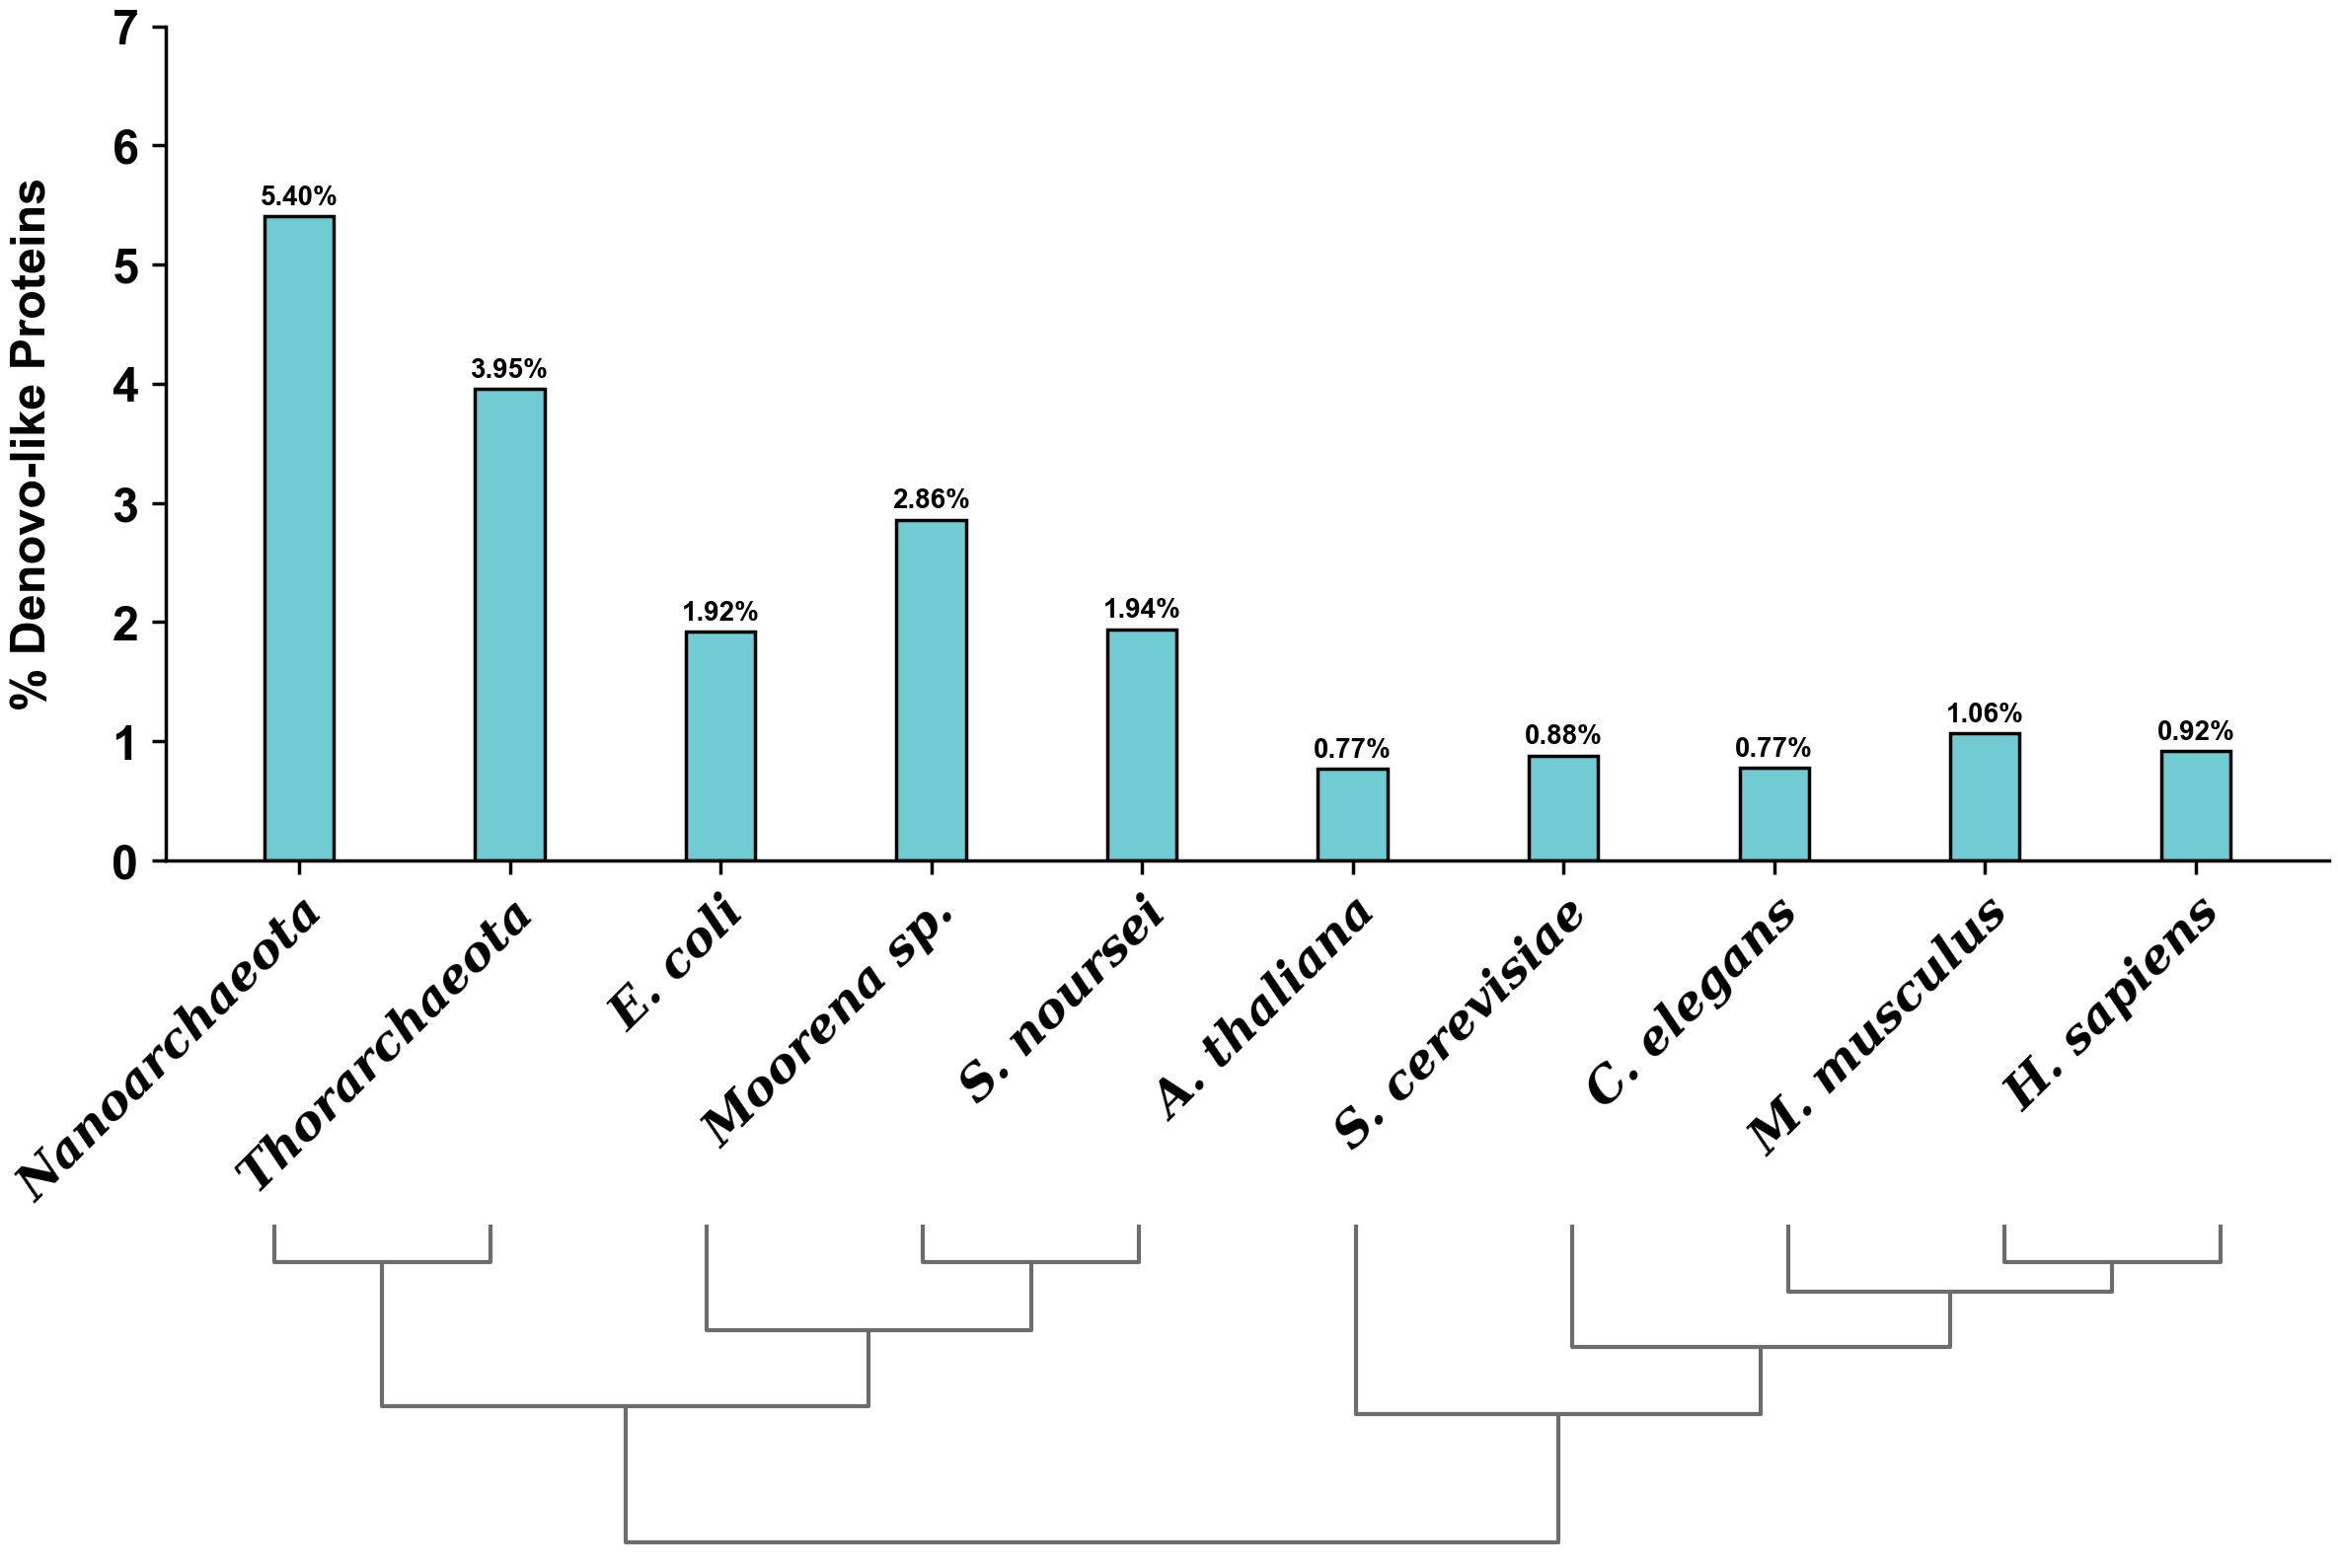


Summary Statistics:
Total OSs analyzed: 10
Average % denovo-like (score > 0.5): 2.047%
Highest % denovo-like: 5.405% (Nanoarchaeota)
Lowest % denovo-like: 0.766% (A. thaliana)


In [23]:
# plot_df = all_results
# Create the plot with phylogenetic tree
if len(plot_df) > 0:

    # Style parameters (matching graph.ipynb)
    STD_COLOR = '0.0'
    kwargs_title = {'fontsize': 40, 'weight': 'bold', 'color': STD_COLOR}
    kwargs_label = {'fontsize': 35, 'weight': 'bold', 'color': STD_COLOR}
    kwargs_ticks = {'fontsize': 35, 'weight': 'bold', 'color': STD_COLOR}
    kwargs_plots = {'linewidth': 2.5, 'edgecolor': STD_COLOR, 'width': 0.33}
    
    # Phylogenetic tree definition (corrected names to match our data)
    newick = '(Nanoarchaeota,Thorarchaeota,(((((Moorena,S_noursei)),E_coli))),((((((((((M_musculus,H_sapiens),C_elegans)),S_cerevisiae))),A_thaliana)))));'
    t = Tree(newick, format=1)
    
    # Create mapping between tree names and our organism names
    tree_to_organism = {
        'Nanoarchaeota': 'Nanoarchaeota',
        'Thorarchaeota': 'Thorarchaeota', 
        'Moorena': 'Moorena sp.',
        'S_noursei': 'S. noursei',
        'E_coli': 'E. coli',
        'M_musculus': 'M. musculus',
        'H_sapiens': 'H. sapiens',
        'C_elegans': 'C. elegans',
        'S_cerevisiae': 'S. cerevisiae',
        'A_thaliana': 'A. thaliana'
    }
    
    # Process tree data
    n_nodes = len([node for node in t.traverse() if node.name != ''])
    all_node_names = [node.name for node in t.traverse() if node.name != '']
    index_nodes = {name: i for i, name in enumerate(all_node_names)}
    nodex_index = {i: name for i, name in enumerate(all_node_names)}
    
    # Calculate the raw distance matrix
    dist_matrix = np.zeros((n_nodes, n_nodes))
    for node1, node2 in permutations(all_node_names, 2):
        if node1 == '' or node2 == '' or node1 == node2:
            continue
        dist = t.get_distance(node1, node2)
        i, j = index_nodes[node1], index_nodes[node2]
        dist_matrix[i, j] = dist
    
    # Convert to pairwise distances (1d) and linkage matrix
    d = pdist(dist_matrix)
    z = linkage(d, method='weighted')
    
    # Create the plot with bar chart on top and dendrogram on bottom
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 16), gridspec_kw={'height_ratios': [2.5, 1]})
    
    # Bar plot with single color (like second graph in graph.ipynb)
    bars = ax1.bar(plot_df['organism'], plot_df['high_score_percentage'], 
                  color='#71cbd3', **kwargs_plots)
    
    # Styling for bar plot
    # fig.suptitle("Denovo-like Protein Predictions (Score > 0.5)\n", **kwargs_title)
    ax1.set_ylabel("% Denovo-like Proteins\n", **kwargs_label)
    
    # Set y-axis ticks and labels
    max_val = plot_df['high_score_percentage'].max()
    y_max = int(np.ceil(max_val / 5) * 5)  # Round up to nearest 5
    y_ticks = np.arange(0, y_max + 1, max(1, y_max // 10))
    ax1.set_yticks(y_ticks)
    ax1.set_yticklabels([f'{int(tick)}' for tick in y_ticks], **kwargs_ticks)
    
    # Set x-axis (matching second graph style with proper rotation)
    ax1.set_xticks(range(len(plot_df)))
    ax1.set_xticklabels([f'{name}' for name in plot_df['organism']], 
                       rotation=45, ha='right', rotation_mode='anchor',
                       fontdict={'fontfamily': 'serif', 'fontstyle': 'italic'}, 
                       **kwargs_label)
    
    # Spine styling for bar plot
    for axis in ['bottom', 'left', 'top', 'right']:
        ax1.spines[axis].set_linewidth(2.5)
        ax1.spines[axis].set_color(STD_COLOR)
    
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.tick_params(width=2.5, length=10, pad=10, color=STD_COLOR)
    ax1.grid(False)
    ax1.set_ylim(0, 7)
    # Add value labels on top of bars
    for i, (bar, value) in enumerate(zip(bars, plot_df['high_score_percentage'])):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max_val*0.01,
                f'{value:.2f}%', ha='center', va='bottom',
                fontsize=20, weight='bold', color=STD_COLOR)
    
    # Create dendrogram with mapped labels
    rcParams['lines.linewidth'] = 3
    # rcParams['lines.linecolor'] = 'r'
    dend = dendrogram(z, ax=ax2, labels=[nodex_index[i] for i in range(n_nodes)], 
                      color_threshold=0, above_threshold_color='#6c6c6c')
    ax2.invert_yaxis()

    # Relabeling based on dendogram order leaves
    dend_labels = [nodex_index[i] for i in dend['leaves']]
    for line in ax2.get_lines():
        line.set_linewidth(5) 
    
    # Remove all labels, ticks, spines, and grid for raw tree
    ax2.set_xlabel('')
    ax2.set_ylabel('')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.grid(False)
    
    # Hide all spines
    for axis in ['bottom', 'left', 'top', 'right']:
        ax2.spines[axis].set_visible(False)
    
    plt.tight_layout()
    plt.savefig("./denovo_predictions_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"Total OSs analyzed: {len(plot_df)}")
    print(f"Average % denovo-like (score > 0.5): {plot_df['high_score_percentage'].mean():.3f}%")
    print(f"Highest % denovo-like: {plot_df['high_score_percentage'].max():.3f}% ({plot_df.loc[plot_df['high_score_percentage'].idxmax(), 'organism']})")
    print(f"Lowest % denovo-like: {plot_df['high_score_percentage'].min():.3f}% ({plot_df.loc[plot_df['high_score_percentage'].idxmin(), 'organism']})")
    
else:
    print("No data available for plotting. Please run the pipeline first.")